<a href="https://colab.research.google.com/github/marcolinomsn/data_processing/blob/main/Machine_Learning_%26_Analytics_(40530010055_20250_01).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MVP Análise de Dados e Boas Práticas

**Nome:** Marcolino Matheus de Souza Nascimento

**Matrícula:** 4052025001107

**Dataset:** https://raw.githubusercontent.com/marcolinomsn/machine_learning/refs/heads/main/dataset.csv

# 1 - Escopo, objetivo e definição do problema
Existem diversos modelos meteorológicos de previsão do tempo. Eles podem prever diversas variáveis atmosféricas, sendo a precipitação a variável mais relevante na maioria das situações. A previsão de chuva pode ser desafiadora dependendo da região, do horizonte de previsão (quanto tempo no futuro a previsão diz respeito). Na empresa onde eu trabalho são armazenados diversos modelos meteorológicos de órgãos públicos e também executados internamente. O principal desafio é obter um modelo principal para ser utilizado e/ou a combinação dos modelos disponíveis para produzir algum ensemble.

## 1.1 - Atributos do Dataset
O dataset utilizado reúne rodadas de simulação (run_datetime) de múltiplos modelos, contendo previsões em diferentes horizontes de tempo e comparações com valores observados (OBS).

O conjunto de dados foi obtido a partir de um banco de dados da empresa onde eu trabalho. No entanto, são dados em grande maioria públicos, que podem ser acessados diariamente a partir de seus respectivos sites. A exceção são os modelos WRF NBT, WRF NBK e WRF NB7 que são produzidos na própria infra estruura da empresa. Os dados o bservados são oriundos de fontes públicas como o Instituto Nacional de Meteorologia.

A tabela possui as seguintes colunas:

`run_datetime`: Data e hora da rodada de simulação do modelo meteorológico (momento em que o modelo numérico foi inicializado).

`datetime`: Data e hora da previsão emitida (quando o modelo estima a chuva para o futuro). É usada em conjunto com run_datetime para calcular o horizonte de previsão.

`step` (criada no pré-processamento): Diferença em horas entre datetime e run_datetime. Representa o lead time da previsão (quantas horas à frente da rodada o modelo está prevendo).

`horizon` (criada no pré-processamento): Agrupamento de step em intervalos de previsão (24h, 48h, 72h, 96h, 120h). Facilita a análise de desempenho por prazos distintos.

`precipitation_obs`: Valor observado de precipitação acumulada (mm) no local e período da previsão. É a variável alvo do problema de regressão.

`model`: Nome do modelo meteorológico numérico que gerou a previsão (ex.: ECMWF, GFS, ICON, WRF). Essa coluna é usada antes do pivot, onde cada modelo passa a ser uma variável independente.

`precipitation`: Valor previsto de precipitação (mm) por um modelo meteorológico específico. Após o pivot, cada modelo passa a ocupar uma coluna própria (ex.: GFS, ECMWF, ICON).

## 1.2 - Tipo de Problema
 É um problema de regressão supervisionada em dados tabulares meteorológicos.

## 1.3 - Objetivo do experimento
O presente experimento tem como objetivo avaliar e melhorar previsões de chuva acumulada a partir de diferentes modelos meteorológicos de previsão do tempo.

## 1.4 - Metodologia do experimento

A previsão do tempo através de modelos tem uma particularidade e um desafio que é a **propagação de erros**.

**Propagação de erros**: Conforme o horizonte de previsão aumenta, os erros iniciais são propagados. Previsões de curto prazo (D+1, D+2) tendem a ser mais próximas da realidade, enquanto previsões de longo prazo (D+4, D+5) acumulam incertezas. Devido a isso, um atributo será adicionado para identificar o horizonte de previsão e particionar os dados. Assim, será possível realizar análises isolando horizontes de previsão, ou seja, um resultado focará apenas no horizonte de 24 horas, seguido de outro resultado focado no horizonte de 48 horas, até 120 horas (5 dias).

**A proposta do trabalho é**:
1. Carregar e organizar os dados, criando atributos derivados como horizonte de previsão.
2. Tratar valores ausentes e ajustar a distribuição da variável-alvo.
3. Comparar modelos candidatos (Lineares, Árvores e Ensemble) com um baseline simples.
4. Otimizar hiperparâmetros para buscar o melhor equilíbrio entre viés e variância.
5. Avaliar o desempenho com métricas adequadas (MAE, RMSE, R² e Bias) e analisar limitações.

Esse fluxo permite não apenas identificar qual modelo apresenta melhor desempenho preditivo, mas também compreender em quais horizontes de previsão as estimativas são mais confiáveis. O resultado esperado é fornecer uma base metodológica para avaliar previsões meteorológicas de forma sistemática e reprodutível.

# 2 -  Reprodutibilidade e ambiente

## 2.1 - Importação das bibliotecas necessárias
Esta seção consolida todas as importações de bibliotecas necessárias para a análise, visualização e pré-processamento dos dados.

In [254]:
import random
import sys
import time

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import randint, uniform

from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, confusion_matrix,
    mean_squared_error, mean_absolute_error, r2_score,
    silhouette_score
)
from sklearn.model_selection import (
    KFold, StratifiedKFold, TimeSeriesSplit,
    train_test_split, cross_val_score,
    GridSearchCV, RandomizedSearchCV
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyClassifier, DummyRegressor
from sklearn.ensemble import (
    RandomForestClassifier, RandomForestRegressor,
    GradientBoostingRegressor
)
from sklearn.cluster import KMeans
from xgboost import XGBRegressor

## 2.2 - Seeds fixas para reprodutibilidade.

In [255]:
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
print("Python:", sys.version.split()[0])
print("Seed global:", SEED)

Python: 3.12.11
Seed global: 42


# 3 - Dados: Carga, entendimento e tratamento inicial


## 3.1 - Abertura do conjunto de dados

In [256]:
def open_dataset():
    """
    Load the raw dataset from a remote CSV file and display basic information.

    Return:
        raw_dataset: DataFrame containing the loaded dataset.
    """
    raw_dataset = pd.read_csv("https://raw.githubusercontent.com/marcolinomsn/machine_learning/refs/heads/main/dataset.csv")
    print(f"Total de linhas: {len(raw_dataset)}")
    display(raw_dataset.sample(5))
    print("\nFormato:", raw_dataset.shape)
    print("\nTipos:")
    print(raw_dataset.dtypes)
    print("\nValores ausentes por coluna:")
    print(raw_dataset.isna().sum())
    print(f"\nQuantidade de modelos meteorológicos: {len(raw_dataset.model.unique())} ({', '.join(raw_dataset.model.unique())})")
    run_datetimes = raw_dataset.run_datetime.unique()
    print(f"Quantidade de simulações (rodadas): {len(raw_dataset.run_datetime.unique())} ({run_datetimes.min()} até {run_datetimes.max()})")
    return raw_dataset

## 3.2 - Reorganizando dataset

Aqui será feito a pivotagem do dataset para transformar as linhas que informam qual é o modelo meteorológico em colunas e, assim, reduzir consideravelmente a quantidade de linhas do conjunto. Isso é possível, pois para cada modelo existe um mesmo horário (datetime), ou seja, é possível ter uma coluna de datetime, seguida de colunas para cada modelo.

In [257]:
def dataset_pivot(dataset):
    """
    Pivot dataset so that each forecast model becomes a column.

    Args:
        dataset: DataFrame containing columns "run_datetime", "datetime",
                 "precipitation_obs", "model", and "precipitation".

    Return:
        dataset: pivoted DataFrame with:
            - "run_datetime": model initialization datetime.
            - "datetime": forecast datetime.
            - "OBS": observed precipitation.
            - One column per forecast model with precipitation predictions.
    """
    dataset = dataset.pivot_table(
        index=["run_datetime", "datetime", "precipitation_obs"],
        columns="model",
        values="precipitation"
    ).reset_index()
    dataset.columns.name = None
    dataset.rename(columns={"precipitation_obs": "OBS"}, inplace=True)
    return dataset

## 3.3 - Criando feature de horizonte da previsão

O horizonte da previsão é importante nesse tipo de dado, pois um modelo meteorológico executado em um dia D com o objetivo de realizar previsões para os horizontes D+0, D+1, D+2, entre outros, tende a apresentar maiores erros em função do aumento do horizonte previsão. Quanto maior for o horizonte, mais erros relacionados a condição inicial do experimento são propagados e influenciam nos resultados. Sendo assim, é plausível pensar que D+0, ou seja, uma previsão de menos de 24 horas, contenha menos erros propagados que uma previsão D+4, para mais de 96 horas. Seguinte essa lógica, o dataset será segmentado em horizontes e serão obtidos resultados diferentes para cada horizonte.

In [258]:
def adding_horizon_feature(dataset):
    """
    Add forecast horizon feature to the dataset based on datetime and run_datetime.

    Args:
        dataset: DataFrame containing "datetime" and "run_datetime" columns.

    Return:
        dataset: DataFrame with two new columns:
            - "step": forecast lead time in hours.
            - "horizon": categorical horizon grouped into intervals.
    """
    dataset.loc[:, "step"] = (
        pd.to_datetime(dataset.datetime) - pd.to_datetime(dataset.run_datetime)
    ).dt.total_seconds() / 3600

    dataset["horizon"] = pd.cut(
        dataset["step"],
        bins=[0, 24, 48, 72, 96, 121],
        labels=[24, 48, 72, 96, 120],
        right=False
    ).astype(int)
    return dataset

## 3.4 - Limpeza de dados

As simulações dos modelos não possuem dados nulos, pois é um dado sintetizado. Contudo, a coluna do dataset correspondente aos dados observados está suscetível à disponibilidades variáveis. Ausências de dados podem ocorrer devido a fatores diversos como manutenção, atraso, erros, etc. Então, será feita a limpeza dos horários que possuem NaN.

In [259]:
def remove_null_values(dataset):
    """
    Remove rows with missing values from the dataset.

    Args:
        dataset: DataFrame possibly containing missing values (NaN).

    Return:
        new_dataset: DataFrame with rows containing null values removed.
    """
    print(f"Total de linhas antes da limpeza: {len(dataset)}")
    new_dataset = dataset.dropna()
    print(f"Total de linhas após a limpeza: {len(new_dataset)}")
    return new_dataset

## 3.5 - Reorganização do dataset e **subconjuntos**

### 3.5.1 - Balanceamento de chuva e não chuva
Antes de treinar os modelos de previsão, é importante preparar os dados para reduzir vieses e facilitar a análise.
- O problema de previsão de chuva apresenta um desbalanceamento: cerca de 70% dos registros são dias sem chuva e apenas 30% têm chuva observada.
- Esse desbalanceamento pode fazer com que os modelos aprendam a “chutar sempre zero” e ainda assim tenham bons resultados em métricas superficiais.
- Para corrigir isso, a função `dataset_balance` separa o dataset em dois subconjuntos.
- Em seguida, é feito um subamostragem aleatória (undersampling) do conjunto sem chuva, pegando o mesmo número de linhas que existe no conjunto com chuva.
- Por fim, os dois subconjuntos são unidos, gerando um dataset balanceado (50% chuva, 50% sem chuva).

In [260]:
def dataset_balance(dataset):
    """
    Balance dataset by undersampling the majority class (no rain).

    Args:
        dataset: DataFrame containing an "OBS" column with observed values.
                 Values greater than 0 represent rain, and 0 represents no rain.

    Return:
        dataset_balanced: DataFrame with equal number of rain and no-rain samples.
                          The no-rain subset is randomly undersampled to match the
                          number of rain observations.
    """
    dataset = dataset.copy()
    dataset_rain = dataset[dataset["OBS"] > 0]
    dataset_no_rain = dataset[dataset["OBS"] == 0]

    dataset_no_rain_sample = dataset_no_rain.sample(len(dataset_rain), random_state=42)
    dataset_balanced = pd.concat([dataset_rain, dataset_no_rain_sample])

    print("\nContagem de linhas:")
    print(f"- Apenas chuva: {len(dataset_rain)}")
    print(f"- Sem chuva: {len(dataset_no_rain)}")
    print(f"- Dataset balanceado: {len(dataset_balanced)}")

    return dataset_balanced

### 3.5.2 - Criação de subconjuntos por horizontes de previsão
Os modelos meteorológicos costumam fornecer previsões em diferentes horizontes de tempo (por exemplo, 6h, 12h, 24h, 48h...).

Essa função separa o dataset em subconjuntos por horizonte, criando um dicionário (dict_data) em que cada chave é um horizonte (ex.: 24) e o valor é o subconjunto correspondente.

Isso facilita a análise do desempenho dos modelos em diferentes prazos de previsão, já que muitas vezes o erro cresce com o aumento do horizonte.

In [261]:
def horizon_slice(dataset):
    """
    Split dataset into subsets based on forecast horizon.

    Args:
        dataset: DataFrame containing a column 'horizon' that defines forecast lead times

    Return:
        dict_data: dictionary where keys are horizon values (in hours)
                   and values are the corresponding dataset slices
    """
    dataset = dataset.copy()
    dict_data = {}

    print()
    for horizon in dataset.horizon.unique():
        horizon_data = dataset[dataset.horizon == horizon]
        print(f"- Apenas horizonte de {horizon}h: {len(horizon_data)}")
        dict_data[horizon] = horizon_data

    return dict_data

## 3.6 - Análise estatística dos modelos meteorológicos vs observado
Antes de treinar modelos de machine learning, é essencial entender como cada modelo meteorológico individualmente se relaciona com a variável observada (OBS).

### 3.6.1 - Cálculo de métricas estatísticas para cada modelo meteorológico
A função gera uma heatmap de correlação mostrando a relação entre cada modelo meteorológico e o valor observado de chuva. Isso ajuda a identificar quais modelos têm maior alinhamento com os dados reais e também se existem modelos muito correlacionados entre si (redundância).

`MAE (Mean Absolute Error)`: erro absoluto médio em relação à chuva observada.

`RMSE (Root Mean Squared Error)`: erro quadrático médio, que penaliza mais os erros grandes.

`R² (Coeficiente de Determinação)`: proporção da variabilidade da chuva observada que o modelo consegue explicar.

`Bias (tendência)`: se o modelo tende a superestimar ou subestimar a chuva.

In [262]:
def evaluate_predictions(y_true, y_pred):
    """
    Compute evaluation metrics comparing predictions with observed values.

    Args:
        y_true: array-like, true observed values
        y_pred: array-like, predicted values (from model or raw forecasts)

    Return:
        dict: dictionary with metrics MAE, RMSE, R2 and BIAS.
    """
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    bias = np.mean(y_pred - y_true)
    return {"MAE": mae, "RMSE": rmse, "R2": r2, "BIAS": bias}

In [263]:
def obs_model_correlation_plot(dataset):
    """
    Compute error metrics and plot correlation heatmap between observed rainfall and forecast models.

    Args:
        dataset: DataFrame containing observed rainfall ("OBS") and model forecasts.

    Return:
        stats_df: DataFrame with MAE, RMSE, R2, and Bias for each forecast model.
    """
    dataset = dataset.copy()

    stats = {}
    for feature in features:
        stats[feature] = evaluate_predictions(dataset["OBS"], dataset[feature])

    stats_df = pd.DataFrame(stats).T
    corr = dataset[["OBS"] + features].corr()
    mask = np.triu(np.ones_like(corr, dtype=bool))

    print("\n")
    plt.figure(figsize=(8,6))
    sns.heatmap(corr, mask=mask, annot=True, cmap="coolwarm", center=0, fmt=".2f")
    plt.title("Correlation heatmap (models vs observed)")
    plt.show()

### 3.6.2 - Estatísticas individuais dos modelos meteorológicos

Essa função serve para avaliar, antes de qualquer treinamento supervisionado, como cada modelo meteorológico se compara ao valor observado de chuva.
Essa análise é importante para a conclusão do experimento a respeito de algum modelo meteorológico já se aproximar bem do observado ou se a combinação (ensemble) ser mais promissora.

In [264]:
def individual_model_statistic(dataset):
    """
    Compute error metrics for each forecast model individually and for the ensemble mean,
    then visualize results with bar charts.

    Args:
        dataset: DataFrame containing observed rainfall ("OBS") and model forecasts.

    Return:
        stats_df: DataFrame with MAE, RMSE, R2, and Bias for each forecast model and the mean model.
    """
    # Calculate metrics for each individual model
    stats = {}
    for feature in features:
        mae = mean_absolute_error(dataset["OBS"], dataset[feature])
        rmse = np.sqrt(mean_squared_error(dataset["OBS"], dataset[feature]))
        r2 = r2_score(dataset["OBS"], dataset[feature])
        bias = np.mean(dataset[feature] - dataset["OBS"])  # positive = overestimate, negative = underestimate
        stats[feature] = {"MAE": mae, "RMSE": rmse, "R2": r2, "Bias": bias}

    # Add medium model
    dataset["MEAN_MODEL"] = dataset[features].mean(axis=1)
    mae = mean_absolute_error(dataset["OBS"], dataset["MEAN_MODEL"])
    rmse = np.sqrt(mean_squared_error(dataset["OBS"], dataset["MEAN_MODEL"]))
    r2 = r2_score(dataset["OBS"], dataset["MEAN_MODEL"])
    bias = np.mean(dataset["MEAN_MODEL"] - dataset["OBS"])
    stats["MEAN_MODEL"] = {"MAE": mae, "RMSE": rmse, "R2": r2, "Bias": bias}

    # DataFrame with results
    stats_df = pd.DataFrame(stats).T
    print("\n")
    print(stats_df)
    print("\n")

    # Stacked bar chart
    metrics = ["MAE", "RMSE", "Bias"]
    colors = ["#1f77b4", "#ff7f0e", "#2ca02c"]

    ax = stats_df[metrics].plot(
        kind="bar",
        figsize=(10, 4),
        color=colors,
        width=.75
    )

    plt.title("Erro por modelo meteorológico vs Observado")
    plt.ylabel("Erro acumulado (mm)")
    plt.xticks(rotation=45)
    plt.legend(title="Métricas")
    plt.tight_layout()
    plt.show()

    # Separate R² graph
    plt.figure(figsize=(10, 3))
    stats_df["R2"].plot(kind="bar", color="purple", width=0.6)
    plt.title("R² por modelo meteorológico")
    plt.ylabel("R²")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# 4 - Divisão dos dados em conjunto de treino e teste

In [265]:
def split_train_test(dataset, features, target, test_size=0.2, random_state=42):
    """
    Split dataset into training and test sets.

    Args:
        dataset: DataFrame with features and target
        features: list of feature column names
        target: target column name
        test_size: fraction of data reserved for test (default 0.2)
        random_state: seed for reproducibility

    Return:
        X_train: training features
        X_test: test features
        y_train: training target
        y_test: test target
    """
    X = dataset[features].copy()
    y = dataset[target].copy()

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state
    )

    print("\nTarget mean - Train:", y_train.mean())
    print("Target mean - Test:", y_test.mean())
    print("Train:", X_train.shape, "| Test:", X_test.shape)

    return X_train, X_test, y_train, y_test

# 5 - **Pipeline** de pré-processamento
A função build_preprocess_pipeline cria um pipeline para tratar as variáveis numéricas:
- Substitui valores ausentes pela **mediana**.
- Aplica **padronização** (média = 0, desvio = 1).
- Mantém as demais colunas sem alteração.

Isso garante que os dados estejam preparados e em escala adequada antes do treinamento dos modelos.

In [266]:
def build_preprocess_pipeline(X):
    """
    Build preprocessing pipeline for numerical features.

    Args:
        X: DataFrame with input features

    Return:
        preprocess: ColumnTransformer that imputes missing values and scales numeric columns
    """
    num_cols = X.select_dtypes(include=["float64", "int64"]).columns.tolist()

    numeric_pipe = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])

    preprocess = ColumnTransformer(
        transformers=[("num", numeric_pipe, num_cols)],
        remainder="passthrough"
    )
    return preprocess

# 6 - Baseline e modelos candidatos
Criação de pipelines de regressão que serão testados:
- **Baseline**: um `DummyRegressor` que prevê sempre a mediana do target, servindo como referência mínima.
- **Modelos candidatos**: diferentes algoritmos de regressão, todos combinados com o pipeline de pré-processamento (`preprocess`), incluindo:
  - Regressões lineares (Linear, Ridge, Lasso)
  - Modelos de ensemble (RandomForest, GradientBoosting, XGBoost)

Essa etapa organiza todos os modelos em uma estrutura padronizada para facilitar o treinamento e a comparação de desempenho.

In [267]:
def build_models(preprocess):
    """
    Build baseline and candidate regression models with preprocessing pipelines.

    Args:
        preprocess: preprocessing pipeline (ColumnTransformer)

    Return:
        baseline: DummyRegressor pipeline
        candidates: dict of model pipelines
    """
    baseline = Pipeline(steps=[
        ("pre", preprocess),
        ("model", DummyRegressor(strategy="median"))
    ])

    candidates = {
        "Linear": Pipeline([
            ("pre", preprocess), ("model", LinearRegression())
        ]),
        "Ridge": Pipeline([
            ("pre", preprocess), ("model", Ridge(alpha=1.0, random_state=SEED))
        ]),
        "Lasso": Pipeline([
            ("pre", preprocess), ("model", Lasso(alpha=0.01, random_state=SEED))
        ]),
        "RandomForest": Pipeline([
            ("pre", preprocess), ("model", RandomForestRegressor(
                n_estimators=300, max_depth=10, random_state=SEED, n_jobs=-1))
        ]),
        "GradientBoosting": Pipeline([
            ("pre", preprocess), ("model", GradientBoostingRegressor(
                n_estimators=300, learning_rate=0.05, max_depth=5, random_state=SEED))
        ]),
        "XGBoost": Pipeline([
            ("pre", preprocess), ("model", XGBRegressor(
                n_estimators=300, learning_rate=0.05, max_depth=5,
                subsample=0.8, colsample_bytree=0.8, random_state=SEED))
        ])
    }
    baseline
    return baseline, candidates

# 7 - Treino e avaliação rápida (baseline vs candidatos)
Essa etapa compara diferentes modelos com um baseline simples, avaliando sua capacidade de generalizar para novos dados. O objetivo é identificar quais algoritmos realmente trazem ganhos em relação a uma referência mínima, considerando não só a qualidade das previsões, mas também o custo de treinamento.

In [268]:
def train_and_evaluate_models(baseline, candidates, X_train, y_train, X_test, y_test):
    """
    Train baseline and candidate models, evaluate performance and track training time.

    Args:
        baseline: pipeline with baseline model
        candidates: dict of model pipelines
        X_train: training features
        y_train: training target
        X_test: test features
        y_test: test target

    Return:
        results_df: DataFrame with evaluation metrics and training times
    """
    results = {}

    # Baseline
    t0 = time.time()
    baseline.fit(X_train, y_train)
    t1 = time.time()

    y_pred = baseline.predict(X_test)
    results["baseline"] = evaluate_predictions(y_test, y_pred)
    results["baseline"]["train_time_s"] = round(t1 - t0, 3)

    # Candidates
    for name, pipe in candidates.items():
        t0 = time.time()
        pipe.fit(X_train, y_train)
        t1 = time.time()

        y_pred = pipe.predict(X_test)
        results[name] = evaluate_predictions(y_test, y_pred)
        results[name]["train_time_s"] = round(t1 - t0, 3)

    results_df = pd.DataFrame(results).T
    return results_df

# 8 - Validação e Otimização de Hiperparâmetros
O desempenho de um modelo depende tanto do algoritmo utilizado quanto dos valores escolhidos para seus hiperparâmetros, como profundidade das árvores ou número de estimadores. O processo de tuning de hiperparâmetros consiste em explorar diferentes combinações desses valores para encontrar o melhor equilíbrio entre viés e variância.

A validação cruzada é usada nesse processo para avaliar várias configurações de forma consistente, reduzindo a influência de divisões específicas do conjunto de treino e fornecendo uma escolha mais robusta do modelo final.

In [269]:

def build_search(preprocess, n_splits=5):
    """
    Build RandomizedSearchCV for RandomForest with preprocessing pipeline.

    Args:
        preprocess: preprocessing pipeline (ColumnTransformer)
        n_splits: number of cross-validation splits

    Return:
        search: RandomizedSearchCV object
    """
    # Cross-validation configuration
    cv = KFold(n_splits=n_splits, shuffle=True, random_state=SEED)

    # Pipeline base definition
    model = Pipeline([
        ("pre", preprocess),
        ("model", RandomForestRegressor(random_state=SEED))
    ])

    # Hyperparameter search space
    param_dist = {
        "model__n_estimators": randint(100, 400),
        "model__max_depth": randint(3, 20),
        "model__min_samples_split": randint(2, 10)
    }

    # RandomizedSearchCV
    search = RandomizedSearchCV(
        estimator=model,
        param_distributions=param_dist,
        n_iter=20,
        scoring="neg_root_mean_squared_error",
        n_jobs=-1,
        cv=cv,
        random_state=SEED,
        verbose=1
    )
    return search


def tune_model(search, X_train, y_train, X_test, y_test):
    """
    Run hyperparameter tuning and evaluate the best model.

    Args:
        search: RandomizedSearchCV object
        X_train: training features
        y_train: training target
        X_test: test features
        y_test: test target

    Return:
        best_model: best model
    """
    t0 = time.time()
    search.fit(X_train, y_train)
    t1 = time.time()

    print(f"\nMelhores parâmetros:")
    print(pd.Series(search.best_params_))

    print(f"\nMelhor pontuação de CV: {search.best_score_:.3f}")

    # Evaluation on the test set
    best_model = search.best_estimator_
    y_pred = best_model.predict(X_test)

    best_results = evaluate_predictions(y_test, y_pred)
    best_results["train_time_s"] = round(t1 - t0, 3)

    print("\nDesempenho do conjunto de teste (best model):")
    print(pd.Series(best_results))

    return best_model

In [270]:
def best_model_plot(X_test, y_test, best_model):
    """
    Plot the best model's predictions against the true values.

    Args:
        X_test: test features
        y_test: test target
        best_model: best model
    """
    print()
    y_pred = best_model.predict(X_test)
    plt.figure(figsize=(8, 6))
    plt.scatter(y_test, y_pred, alpha=0.5)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "k--", lw=2)
    plt.xlabel("Observado")
    plt.ylabel("Previsto")
    plt.title("Observado vs. Previsto - Melhor Modelo")
    plt.show()

# 9 - Execução principal

## 9.1 - Carga e tratamento principal do conjunto de dados

In [277]:
raw_dataset = open_dataset()
dataset = dataset_pivot(raw_dataset)
dataset = adding_horizon_feature(dataset)
dataset = remove_null_values(dataset)

# Definição de features e target
target = "OBS"
features = ["ECMWF", "GFS", "ICON", "WRF"]#, "WRF NB7", "WRF NBK", "WRF NBT"]

print("\nPROBLEM_TYPE: Regressão")
print("Target:", target)
print("N features:", len(features))

# dataset_balanced = dataset_balance(dataset)
# dict_data = horizon_slice(dataset_balanced)

dict_data = horizon_slice(dataset)

Total de linhas: 457102


,region,state,model,run_datetime,datetime,precipitation,precipitation_obs
149557,BR-116 - 04 Monte Castelo - SC,SC,GFS,2025-06-11 00:00:00+00:00,2025-06-12 01:00:00+00:00,0.00,0.00
400773,BR-116 - 06 Santa Cecília - SC,SC,GFS,2025-06-20 00:00:00+00:00,2025-06-24 02:00:00+00:00,0.00,0.12
188884,BR-116 - 04 Monte Castelo - SC,SC,WRF,2025-06-30 00:00:00+00:00,2025-07-03 11:00:00+00:00,0.02,0.00
259768,BR-116 - 05 Serra do Espigão - SC,SC,ECMWF,2025-07-11 00:00:00+00:00,2025-07-13 15:00:00+00:00,0.01,0.00
24648,BR-116 - 03 Mafra - SC,SC,GFS,2025-06-12 00:00:00+00:00,2025-06-12 22:00:00+00:00,0.00,NaN



Formato: (457102, 7)

Tipos:
region                object
state                 object
model                 object
run_datetime          object
datetime              object
precipitation        float64
precipitation_obs    float64
dtype: object

Valores ausentes por coluna:
region                   0
state                    0
model                    0
run_datetime             0
datetime                 0
precipitation            0
precipitation_obs    40325
dtype: int64

Quantidade de modelos meteorológicos: 7 (ECMWF, GFS, ICON, WRF, WRF NB7, WRF NBK, WRF NBT)
Quantidade de simulações (rodadas): 155 (2025-04-20 00:00:00+00:00 até 2025-09-21 00:00:00+00:00)
Total de linhas antes da limpeza: 28362
Total de linhas após a limpeza: 17847

PROBLEM_TYPE: Regressão
Target: OBS
N features: 4

- Apenas horizonte de 48h: 3542
- Apenas horizonte de 72h: 3530
- Apenas horizonte de 96h: 3539
- Apenas horizonte de 120h: 3706
- Apenas horizonte de 24h: 3530


## 9.2 - Horizonte de 24 horas

,OBS,ECMWF,GFS,ICON,WRF,WRF NB7,WRF NBK,WRF NBT,step,horizon
count,3530.000000,3530.000000,3530.000000,3530.000000,3530.000000,3530.000000,3530.000000,3530.000000,3530.000000,3530.0
mean,0.234569,0.258387,0.224002,0.186267,0.276599,0.300623,0.296000,0.323946,11.404249,24.0
std,1.013672,0.867556,0.868485,0.759991,0.927620,1.440511,1.487202,1.320849,6.742735,0.0
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,24.0
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,24.0
50%,0.000000,0.000000,0.000000,0.000000,0.007500,0.000000,0.000000,0.006667,11.000000,24.0
75%,0.050000,0.060000,0.060000,0.002500,0.090000,0.000000,0.036667,0.090000,17.000000,24.0
max,18.360000,11.320000,11.190000,11.790000,9.760000,25.990000,28.900000,23.290000,23.000000,24.0


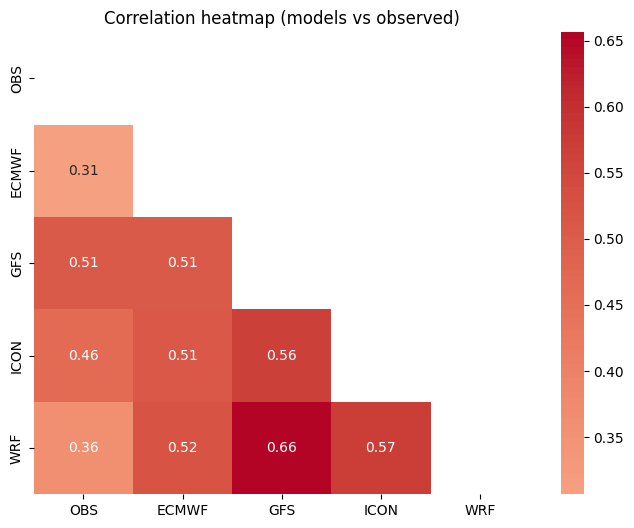



                 MAE      RMSE        R2      Bias
ECMWF       0.323019  1.114034 -0.208163  0.023818
GFS         0.255042  0.943328  0.133730 -0.010567
ICON        0.255800  0.945248  0.130200 -0.048302
WRF         0.323344  1.097852 -0.173320  0.042029
MEAN_MODEL  0.259998  0.899566  0.212239  0.001744




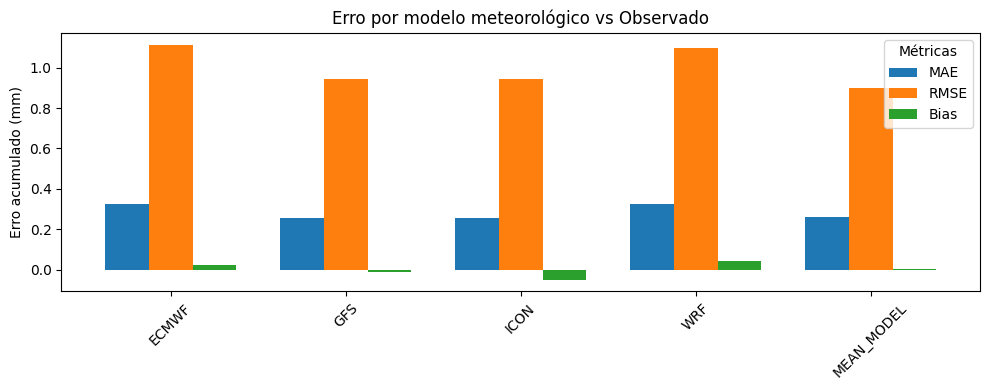

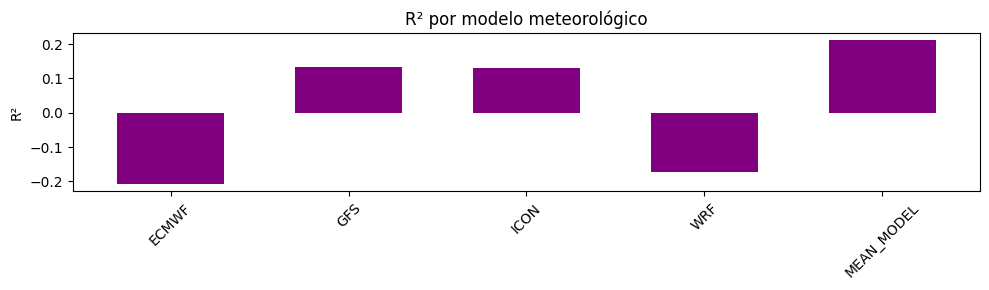


Target mean - Train: 0.22589235127478757
Target mean - Test: 0.2692776203966006
Train: (2824, 4) | Test: (706, 4)




,MAE,RMSE,R2,BIAS,train_time_s
baseline,0.269278,1.306991,-0.044329,-0.269278,0.009
Linear,0.303299,1.068083,0.302567,-0.044266,0.008
Ridge,0.303317,1.068128,0.302508,-0.044258,0.008
Lasso,0.305311,1.070428,0.299502,-0.044285,0.008
RandomForest,0.304784,1.046086,0.330998,-0.015554,1.100
GradientBoosting,0.308185,1.086246,0.278646,-0.030892,1.233
XGBoost,0.293820,1.028880,0.352825,-0.036830,1.005




Fitting 2 folds for each of 20 candidates, totalling 40 fits

Melhores parâmetros:
model__max_depth              4
model__min_samples_split      9
model__n_estimators         376
dtype: int64

Melhor pontuação de CV: -0.811

Desempenho do conjunto de teste (best model):
MAE              0.303875
RMSE             1.062481
R2               0.309864
BIAS            -0.027702
train_time_s    31.862000
dtype: float64



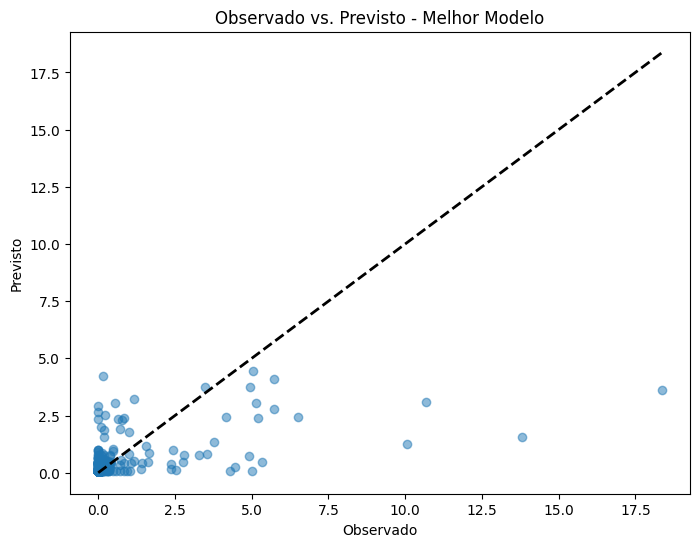

In [272]:
horizon = 24
h_dataset = dict_data[horizon]
display(h_dataset.describe())

obs_model_correlation_plot(h_dataset)
individual_model_statistic(h_dataset)
X_train, X_test, y_train, y_test = split_train_test(h_dataset, features, target)
preprocess = build_preprocess_pipeline(X_train)
baseline, candidates = build_models(preprocess)

results_df = train_and_evaluate_models(
    baseline, candidates, X_train, y_train, X_test, y_test
)

print("\n")
display(results_df)
print("\n")

search = build_search(preprocess, 2)
best_model = tune_model(search, X_train, y_train, X_test, y_test)
best_model_plot(X_test, y_test, best_model)

## 9.3 - Horizonte de 48 horas

,OBS,ECMWF,GFS,ICON,WRF,WRF NB7,WRF NBK,WRF NBT,step,horizon
count,3542.000000,3542.000000,3542.000000,3542.000000,3542.000000,3542.000000,3542.000000,3542.000000,3542.000000,3542.0
mean,0.232564,0.301199,0.193127,0.193132,0.259918,0.257862,0.313109,0.316690,35.403162,48.0
std,1.011779,0.985714,0.744737,0.851918,0.782481,1.106694,1.382283,1.023592,6.741030,0.0
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,24.000000,48.0
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,30.000000,48.0
50%,0.000000,0.002500,0.000000,0.000000,0.015000,0.000000,0.000000,0.010000,35.000000,48.0
75%,0.050000,0.081875,0.040000,0.003333,0.110000,0.000000,0.060000,0.120000,41.000000,48.0
max,18.360000,13.630000,15.250000,18.010000,10.350000,14.770000,25.080000,16.800000,47.000000,48.0


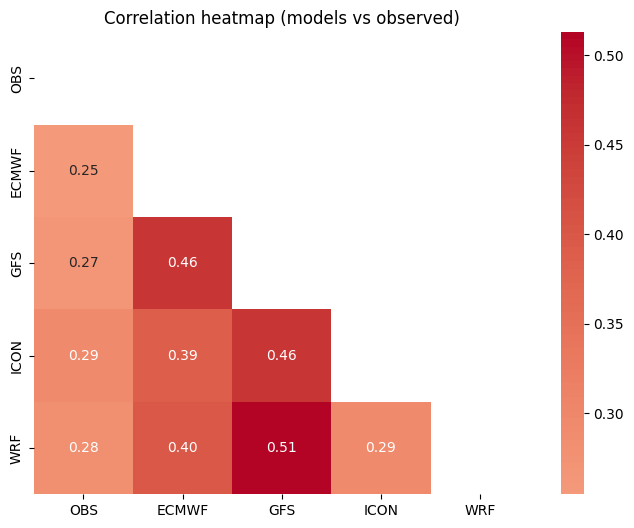



                 MAE      RMSE        R2      Bias
ECMWF       0.368187  1.221283 -0.457416  0.068636
GFS         0.297729  1.084114 -0.148421 -0.039436
ICON        0.287680  1.114947 -0.214674 -0.039432
WRF         0.345548  1.090016 -0.160959  0.027355
MEAN_MODEL  0.295036  0.977051  0.067206  0.004281




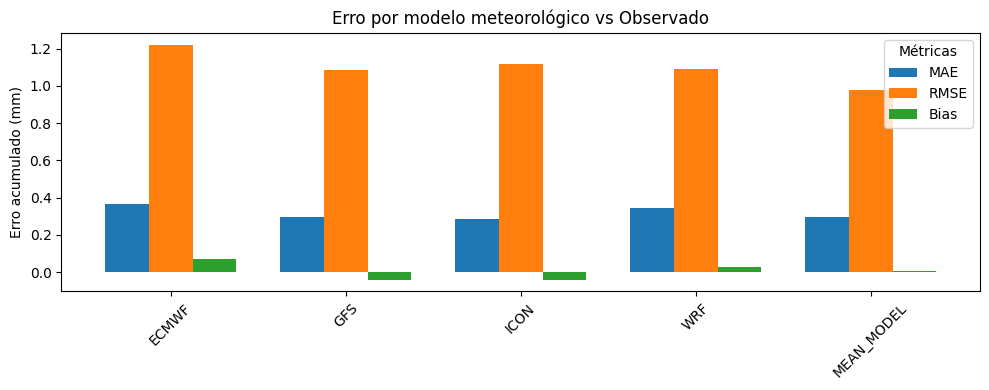

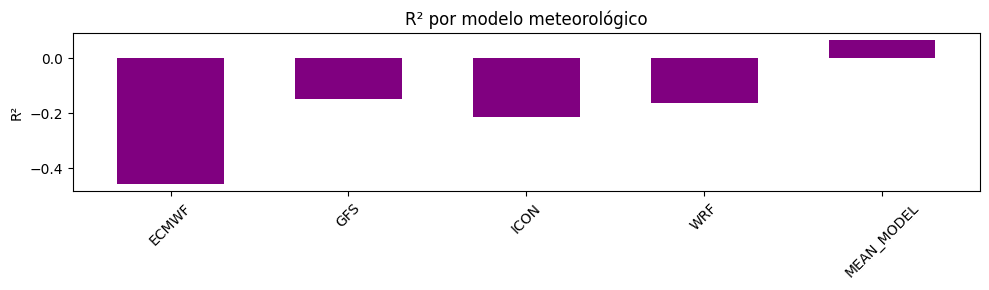


Target mean - Train: 0.23906459583480408
Target mean - Test: 0.20658674188998588
Train: (2833, 4) | Test: (709, 4)




,MAE,RMSE,R2,BIAS,train_time_s
baseline,0.206587,1.080600,-0.037935,-0.206587,0.008
Linear,0.310161,1.032047,0.053241,0.022971,0.009
Ridge,0.310167,1.032038,0.053258,0.022976,0.008
Lasso,0.311296,1.030793,0.055542,0.023194,0.008
RandomForest,0.319534,1.101161,-0.077809,0.044588,1.163
GradientBoosting,0.329713,1.196885,-0.273342,0.037679,1.040
XGBoost,0.332146,1.118946,-0.112905,0.033050,0.171




Fitting 2 folds for each of 20 candidates, totalling 40 fits

Melhores parâmetros:
model__max_depth              6
model__min_samples_split      2
model__n_estimators         113
dtype: int64

Melhor pontuação de CV: -0.893

Desempenho do conjunto de teste (best model):
MAE              0.306625
RMSE             1.089386
R2              -0.054881
BIAS             0.031052
train_time_s    30.264000
dtype: float64



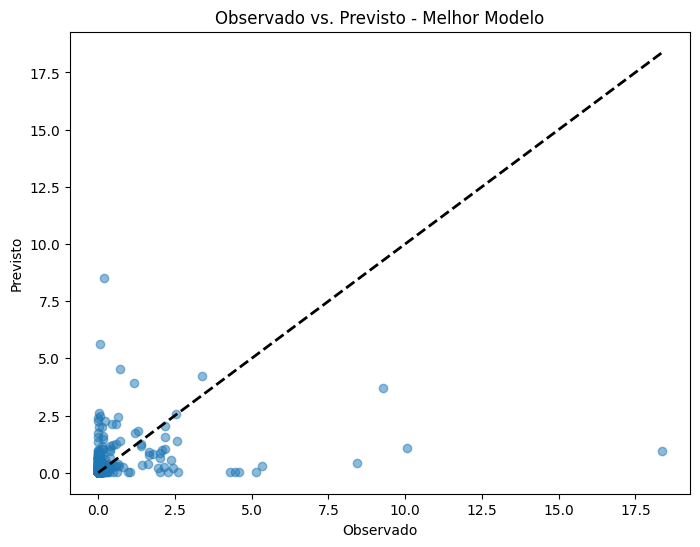

In [273]:
horizon = 48
h_dataset = dict_data[horizon]
display(h_dataset.describe())

obs_model_correlation_plot(h_dataset)
individual_model_statistic(h_dataset)
X_train, X_test, y_train, y_test = split_train_test(h_dataset, features, target)
preprocess = build_preprocess_pipeline(X_train)
baseline, candidates = build_models(preprocess)

results_df = train_and_evaluate_models(
    baseline, candidates, X_train, y_train, X_test, y_test
)

print("\n")
display(results_df)
print("\n")

search = build_search(preprocess, 2)
best_model = tune_model(search, X_train, y_train, X_test, y_test)
best_model_plot(X_test, y_test, best_model)

## 9.4 - Horizonte de 72 horas

,OBS,ECMWF,GFS,ICON,WRF,WRF NB7,WRF NBK,WRF NBT,step,horizon
count,3530.000000,3530.000000,3530.000000,3530.000000,3530.000000,3530.000000,3530.000000,3530.000000,3530.000000,3530.0
mean,0.226598,0.243035,0.204309,0.208052,0.226785,0.272911,0.301881,0.340412,59.361473,72.0
std,1.003337,0.765564,0.774805,0.859416,0.741223,1.226262,1.266035,1.088325,6.744303,0.0
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,48.000000,72.0
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,54.000000,72.0
50%,0.000000,0.002500,0.000000,0.000000,0.010000,0.000000,0.000000,0.010000,59.000000,72.0
75%,0.040000,0.062500,0.060000,0.006667,0.100000,0.000000,0.070000,0.126667,65.000000,72.0
max,18.360000,7.920000,14.880000,16.520000,10.300000,34.420000,20.890000,14.000000,71.000000,72.0


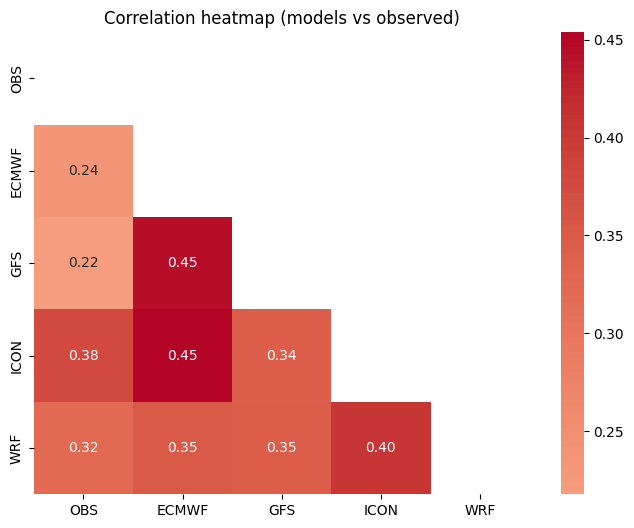



                 MAE      RMSE        R2      Bias
ECMWF       0.334372  1.108545 -0.221059  0.016437
GFS         0.315014  1.126392 -0.260693 -0.022289
ICON        0.285729  1.046141 -0.087453 -0.018546
WRF         0.314796  1.036064 -0.066603  0.000187
MEAN_MODEL  0.282870  0.939671  0.122633 -0.006053




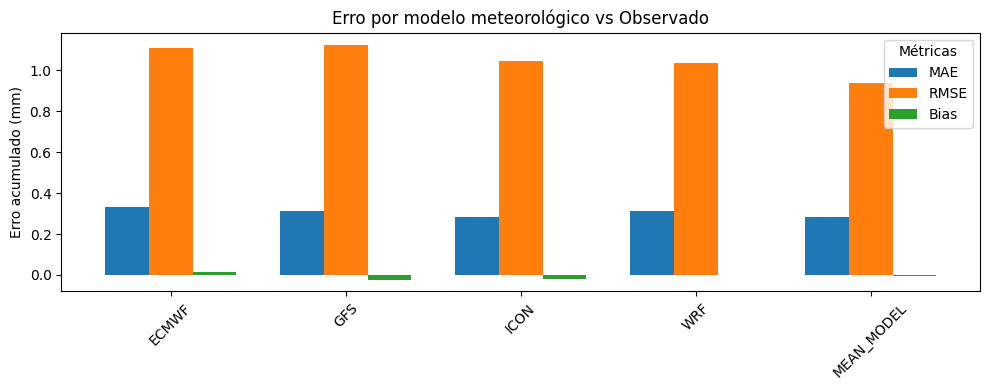

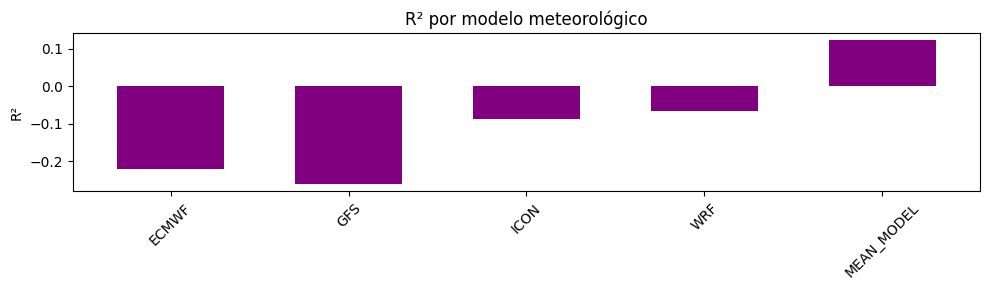


Target mean - Train: 0.23141997167138809
Target mean - Test: 0.2073087818696884
Train: (2824, 4) | Test: (706, 4)




,MAE,RMSE,R2,BIAS,train_time_s
baseline,0.207309,0.959456,-0.048972,-0.207309,0.010
Linear,0.287892,0.842849,0.190507,0.012553,0.007
Ridge,0.287904,0.842858,0.190489,0.012556,0.009
Lasso,0.289984,0.843279,0.189680,0.012838,0.008
RandomForest,0.274798,0.886928,0.103623,0.030730,2.109
GradientBoosting,0.316031,1.045367,-0.245237,0.046301,1.260
XGBoost,0.286690,0.889784,0.097842,0.025216,0.171




Fitting 2 folds for each of 20 candidates, totalling 40 fits

Melhores parâmetros:
model__max_depth              3
model__min_samples_split      5
model__n_estimators         121
dtype: int64

Melhor pontuação de CV: -0.929

Desempenho do conjunto de teste (best model):
MAE              0.280050
RMSE             0.847124
R2               0.182273
BIAS             0.014349
train_time_s    29.592000
dtype: float64



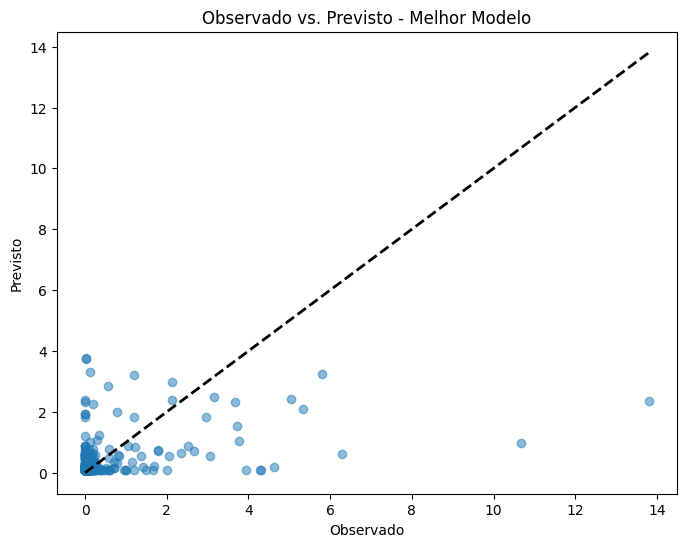

In [274]:
horizon = 72
h_dataset = dict_data[horizon]
display(h_dataset.describe())

obs_model_correlation_plot(h_dataset)
individual_model_statistic(h_dataset)
X_train, X_test, y_train, y_test = split_train_test(h_dataset, features, target)
preprocess = build_preprocess_pipeline(X_train)
baseline, candidates = build_models(preprocess)

results_df = train_and_evaluate_models(
    baseline, candidates, X_train, y_train, X_test, y_test
)

print("\n")
display(results_df)
print("\n")

search = build_search(preprocess, 2)
best_model = tune_model(search, X_train, y_train, X_test, y_test)
best_model_plot(X_test, y_test, best_model)

## 9.5 - Horizonte de 96 horas

,OBS,ECMWF,GFS,ICON,WRF,WRF NB7,WRF NBK,WRF NBT,step,horizon
count,3539.000000,3539.000000,3539.000000,3539.000000,3539.000000,3539.000000,3539.000000,3539.000000,3539.000000,3539.0
mean,0.233673,0.224237,0.211874,0.185412,0.252547,0.308377,0.277730,0.352237,83.371856,96.0
std,1.012512,0.773040,0.759011,0.620484,0.867329,1.353653,1.157307,1.141468,6.743643,0.0
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,72.000000,96.0
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,78.000000,96.0
50%,0.000000,0.002500,0.000000,0.000000,0.010000,0.000000,0.000000,0.015000,83.000000,96.0
75%,0.050000,0.060000,0.060000,0.020000,0.080000,0.020000,0.080000,0.160000,89.000000,96.0
max,18.360000,12.560000,9.120000,6.400000,13.940000,33.810000,25.870000,20.460000,95.000000,96.0


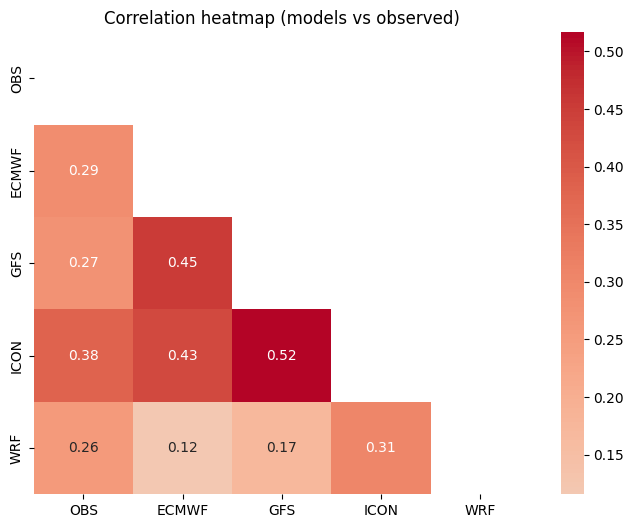



                 MAE      RMSE        R2      Bias
ECMWF       0.309133  1.081241 -0.140689 -0.009437
GFS         0.308011  1.086160 -0.151093 -0.021799
ICON        0.280012  0.965708  0.090056 -0.048261
WRF         0.369639  1.152844 -0.296773  0.018873
MEAN_MODEL  0.285442  0.923401  0.168038 -0.015156




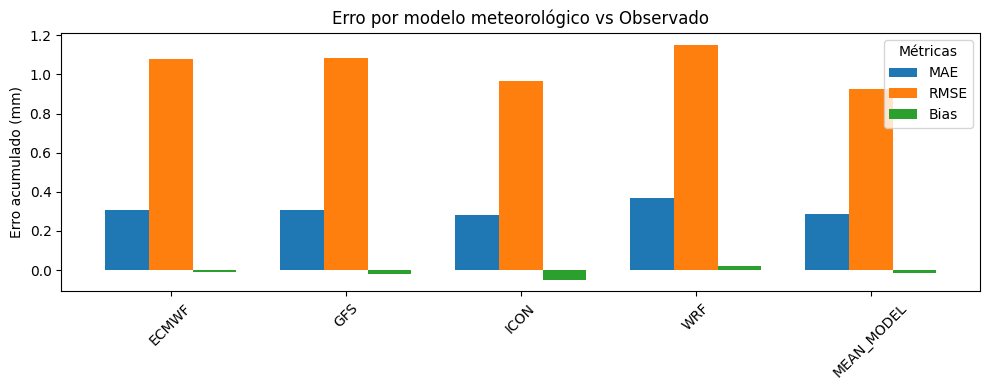

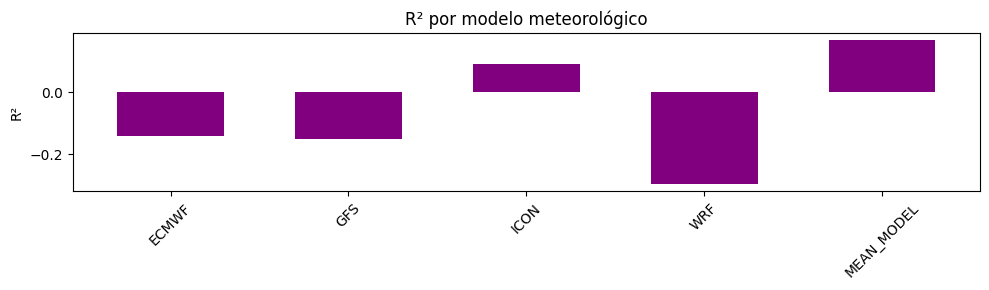


Target mean - Train: 0.2119710349699753
Target mean - Test: 0.32045197740112996
Train: (2831, 4) | Test: (708, 4)




,MAE,RMSE,R2,BIAS,train_time_s
baseline,0.320452,1.476344,-0.049444,-0.320452,0.009
Linear,0.354590,1.316546,0.165443,-0.127892,0.007
Ridge,0.354605,1.316564,0.165421,-0.127889,0.007
Lasso,0.357564,1.319635,0.161522,-0.127080,0.008
RandomForest,0.328718,1.280329,0.210727,-0.120626,1.170
GradientBoosting,0.339599,1.309120,0.174831,-0.119098,1.080
XGBoost,0.336442,1.279928,0.211221,-0.140405,0.169




Fitting 2 folds for each of 20 candidates, totalling 40 fits

Melhores parâmetros:
model__max_depth              4
model__min_samples_split      9
model__n_estimators         376
dtype: int64

Melhor pontuação de CV: -0.797

Desempenho do conjunto de teste (best model):
MAE              0.345645
RMSE             1.302016
R2               0.183763
BIAS            -0.126649
train_time_s    30.860000
dtype: float64



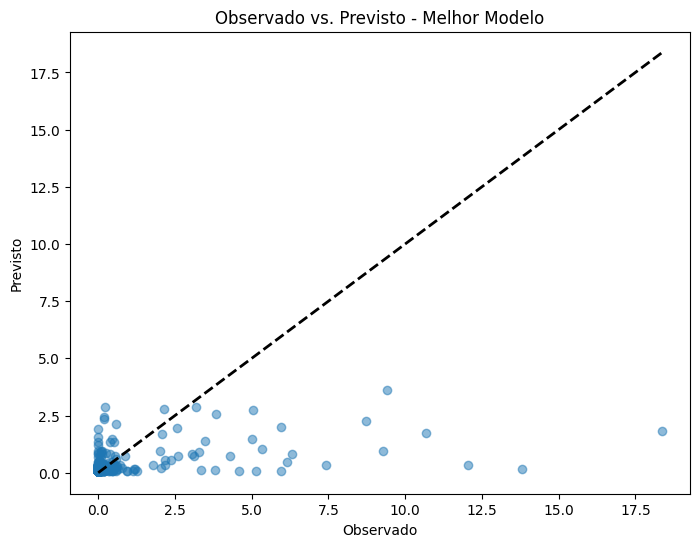

In [275]:
horizon = 96
h_dataset = dict_data[horizon]
display(h_dataset.describe())

obs_model_correlation_plot(h_dataset)
individual_model_statistic(h_dataset)
X_train, X_test, y_train, y_test = split_train_test(h_dataset, features, target)
preprocess = build_preprocess_pipeline(X_train)
baseline, candidates = build_models(preprocess)

results_df = train_and_evaluate_models(
    baseline, candidates, X_train, y_train, X_test, y_test
)

print("\n")
display(results_df)
print("\n")

search = build_search(preprocess, 2)
best_model = tune_model(search, X_train, y_train, X_test, y_test)
best_model_plot(X_test, y_test, best_model)

## 9.6 - Horizonte de 120 horas

,OBS,ECMWF,GFS,ICON,WRF,WRF NB7,WRF NBK,WRF NBT,step,horizon
count,3706.000000,3706.000000,3706.000000,3706.000000,3706.000000,3706.000000,3706.000000,3706.000000,3706.000000,3706.0
mean,0.246784,0.198451,0.272905,0.223707,0.279488,0.440002,0.435355,0.461123,107.868861,120.0
std,1.028198,0.559924,0.927996,0.628175,0.936286,1.584633,1.722240,1.418999,7.049818,0.0
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,96.000000,120.0
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,102.000000,120.0
50%,0.000000,0.005000,0.000000,0.000000,0.013333,0.000000,0.000000,0.013333,108.000000,120.0
75%,0.050000,0.075000,0.075000,0.050000,0.090000,0.040000,0.110000,0.170000,114.000000,120.0
max,18.360000,5.770000,18.190000,7.070000,12.980000,24.240000,40.060000,22.000000,120.000000,120.0


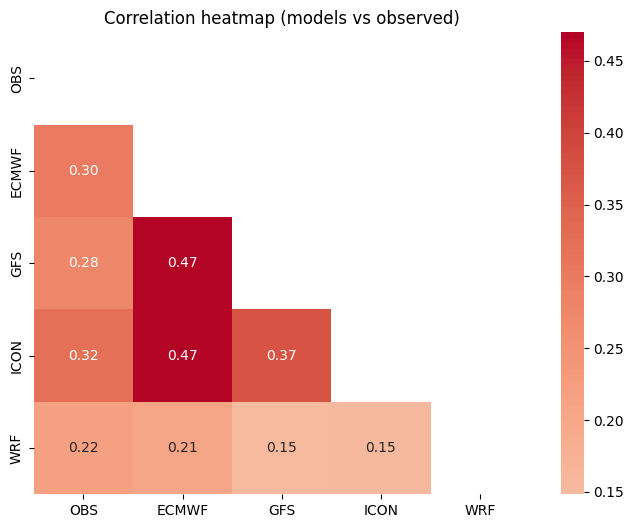



                 MAE      RMSE        R2      Bias
ECMWF       0.305771  1.014695  0.025830 -0.048333
GFS         0.366893  1.177417 -0.311670  0.026122
ICON        0.322479  1.019083  0.017386 -0.023077
WRF         0.415055  1.230408 -0.432391  0.032704
MEAN_MODEL  0.317523  0.949659  0.146705 -0.003146




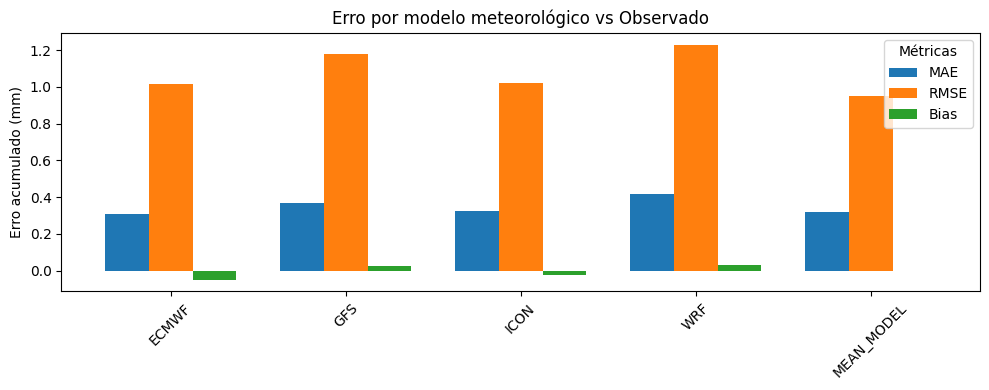

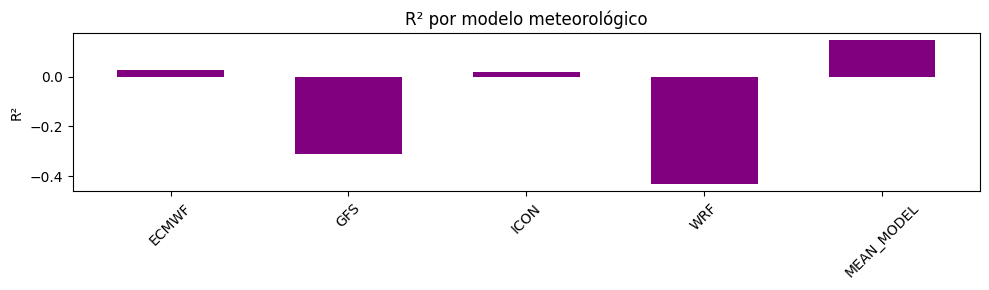


Target mean - Train: 0.253110661268556
Target mean - Test: 0.22150943396226416
Train: (2964, 4) | Test: (742, 4)




,MAE,RMSE,R2,BIAS,train_time_s
baseline,0.221509,0.991479,-0.052536,-0.221509,0.008
Linear,0.305249,0.927879,0.078166,-0.005542,0.008
Ridge,0.305255,0.927873,0.078179,-0.005535,0.008
Lasso,0.306667,0.926712,0.080483,-0.004335,0.009
RandomForest,0.295258,0.961187,0.010795,-0.006984,2.271
GradientBoosting,0.308756,1.037507,-0.152530,-0.004639,1.436
XGBoost,0.301867,0.982732,-0.034048,-0.019317,0.182




Fitting 2 folds for each of 20 candidates, totalling 40 fits

Melhores parâmetros:
model__max_depth              4
model__min_samples_split      9
model__n_estimators         376
dtype: int64

Melhor pontuação de CV: -0.948

Desempenho do conjunto de teste (best model):
MAE              0.304564
RMSE             0.941692
R2               0.050516
BIAS            -0.007302
train_time_s    32.439000
dtype: float64



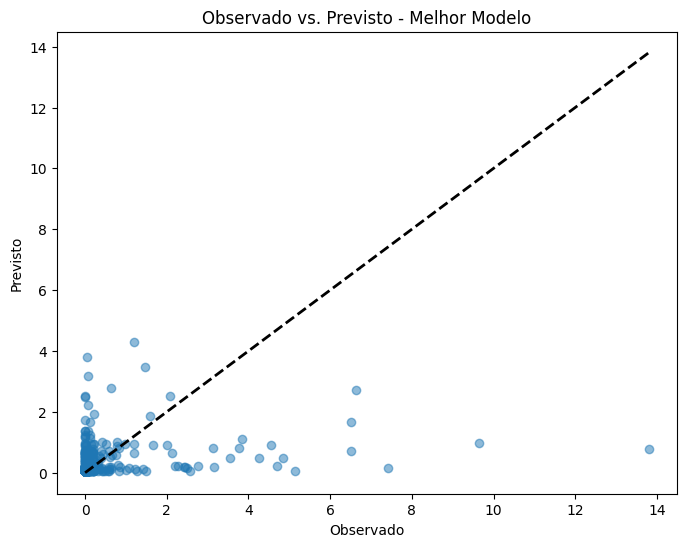

In [276]:
horizon = 120
h_dataset = dict_data[horizon]
display(h_dataset.describe())

obs_model_correlation_plot(h_dataset)
individual_model_statistic(h_dataset)
X_train, X_test, y_train, y_test = split_train_test(h_dataset, features, target)
preprocess = build_preprocess_pipeline(X_train)
baseline, candidates = build_models(preprocess)

results_df = train_and_evaluate_models(
    baseline, candidates, X_train, y_train, X_test, y_test
)

print("\n")
display(results_df)
print("\n")

search = build_search(preprocess, 2)
best_model = tune_model(search, X_train, y_train, X_test, y_test)
best_model_plot(X_test, y_test, best_model)

# 10 - Conclusões e próximos passos
Os resultados mostraram que os modelos meteorológicos isolados têm desempenho limitado, mas a média simples (ensemble simples) já se destaca como baseline, reduzindo erros em relação aos modelos individuais.

Entre os algoritmos de aprendizado supervisionado, os métodos de árvores e ensembles (RandomForest, GradientBoosting e XGBoost) apresentaram os melhores resultados, com menores erros e maior R², sobretudo no horizonte de 24h. À medida que o horizonte aumenta, ocorre a propagação dos erros, mas os ensembles mantêm vantagem em relação às regressões lineares.

A validação cruzada e o tuning de hiperparâmetros mostraram-se fundamentais para evitar overfitting, enquanto métricas adicionais, como o Bias, ajudaram a identificar tendências de superestimação ou subestimação.

**Em resumo:**
1. O ensemble simples supera modelos individuais.
2. Métodos baseados em árvores e boosting capturam melhor relações não lineares.
3. O desempenho decresce com o horizonte, confirmando a propagação de erros.
4. Avaliação com múltiplas métricas foi essencial para compreender limitações e ganhos.

O experimento confirma que a combinação de dados meteorológicos com técnicas de aprendizado supervisionado agrega valor à previsão de precipitação, tornando-a mais robusta e confiável.

# 11 - Próximos passos
Como **próximos passos**, recomenda-se:
- **Organizar os valores de precipitação em acumulado diário.** Pode ser complexo acertar a distribuição de valores horários com exatidão tanto em termos de volume de chuva quanto em termos do momento de ocorrência. Já o acumulado diário, soma essa distribuição e pode representar melhor a chuva observada. Erram-se os horários, mas dentro do período o total se aproxima.
- **Aumentar o período de conjunto de dados.** Foram usados apenas 5 meses de previsão e dados observados. Esse período não aborda as diferentes estações do ano e não aborda variabilidades interanuais. Em termos estatísticos, o conjunto ainda é pequeno e pode não gerar um treinamneto muito robusto.
- **Criar features com lag de precipitação.** Por mais que a precipitação seja uma variável discreta, ou seja, não chove em H+1 por que choveu em H, essa informação pode representar um contexto climático que é já encontra-se favorável a chuva horas antes.
- **Adicionar outras variáveis como nebulosidade, umidade do ar e temperatura.**
- **Adicionar mais fontes de dados observados.** Isso possibilita alternativas quando um dado observado for nulo e também fontes mais confiáveis.